# Read prepared samples

In [50]:
import pickle
import pandas as pd

with open('USDCAD.info.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

w = loaded_dict['window_length']
vocabulary = loaded_dict['vocabulary']
samples = loaded_dict['samples']

samples

,X,y
0,"[USDCAD_0, USDCAD_12, USDCAD_12, USDCAD_7, USD...",USDCAD_1
1,"[USDCAD_0, USDCAD_7, USDCAD_7, USDCAD_7, USDCA...",USDCAD_3
2,"[USDCAD_14, USDCAD_2, USDCAD_12, USDCAD_12, US...",USDCAD_3
3,"[USDCAD_7, USDCAD_0, USDCAD_0, USDCAD_0, USDCA...",USDCAD_3
4,"[USDCAD_13, USDCAD_17, USDCAD_5, USDCAD_3, USD...",USDCAD_12
...,...,...
1430,"[USDCAD_11, USDCAD_0, USDCAD_5, USDCAD_16, USD...",USDCAD_13
1431,"[USDCAD_17, USDCAD_16, USDCAD_5, USDCAD_16, US...",USDCAD_12
1432,"[USDCAD_0, USDCAD_17, USDCAD_5, USDCAD_3, USDC...",USDCAD_17
1433,"[USDCAD_6, USDCAD_17, USDCAD_5, USDCAD_15, USD...",USDCAD_8


# Convert tokens to integers

In [ ]:
id2token = {i: vocabulary[i] for i in range(len(vocabulary))}
token2id = {vocabulary[i]: i for i in range(len(vocabulary))}

In [51]:
def token_to_integer(row):
  row['y'] = token2id[row['y']]
  for i in range(len(row['X'])):
    row['X'][i] = token2id[row['X'][i]]
  row['X'] = row['X'].astype('int')
  return row

samples.apply(token_to_integer, axis=1)

,X,y
0,"[0, 4, 4, 15, 0]",1
1,"[0, 15, 15, 15, 13]",11
2,"[6, 10, 4, 4, 13]",11
3,"[15, 0, 0, 0, 0]",11
4,"[5, 9, 13, 11, 4]",4
...,...,...
1430,"[3, 0, 13, 8, 9]",5
1431,"[9, 8, 13, 8, 9]",4
1432,"[0, 9, 13, 11, 5]",9
1433,"[14, 9, 13, 7, 13]",16


# Train/Test/Validation split

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(samples.X, samples.y, test_size=0.2, random_state=42)
train_data = pd.concat((X_train, y_train), axis=1)
X_train, X_val, y_train, y_val = train_test_split(train_data.X, train_data.y, test_size=0.1, random_state=42)

print(f'X_train:{X_train.shape}  y_train:{y_train.shape}')
print(f'X_test :{X_test.shape}  y_test :{y_test.shape}')
print(f'X_val  :{X_val.shape}   y_val  :{y_val.shape}')

X_train:(1033,)  y_train:(1033,)
X_test :(287,)  y_test :(287,)
X_val  :(115,)   y_val  :(115,)


## Train GPT

In [54]:
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [55]:
class ChartDataset(Dataset):
    def __init__(self, x, y):
      self.x = x
      self.y = y

    def __getitem__(self, idx):
      input = {'input_ids': torch.tensor(self.x[idx]).to(device), 'attention_mask': torch.ones(len(self.x[idx])).to(device)}
      labels = torch.ones(len(self.x[idx]), dtype=torch.long) * -100
      labels[-1] = self.y[idx]
      # labels[-3:-1] = torch.tensor(self.x[idx][-2:])
      labels = labels.to(device)
      return input, labels

    def __len__(self):
      return len(self.y)

train_dataset = ChartDataset(X_train.to_numpy(), y_train.to_numpy())
val_dataset = ChartDataset(X_val.to_numpy(), y_val.to_numpy())
test_dataset = ChartDataset(X_test.to_numpy(), y_test.to_numpy())

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [56]:
def train_one_epoch(model, dataloader, optimizer):
  model.train()
  accu_loss = 0
  for x, y in dataloader:
    optimizer.zero_grad()
    loss = model(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).loss
    accu_loss += loss.item()
    loss.backward()
    optimizer.step()
  overall_loss = accu_loss / len(dataloader)
  return overall_loss

def test_one_epoch(model, dataloader):
  model.eval()
  with torch.no_grad():
    accu_loss = 0
    for x, y in dataloader:
      loss = model(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).loss
      accu_loss += loss.item()
    overall_loss = accu_loss / len(dataloader)
  return overall_loss

In [57]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, GPT2Config

configuration = GPT2Config(vocab_size=len(vocabulary), n_positions=w+1)
gpt_pretrained = GPT2LMHeadModel.from_pretrained('gpt2')
gpt = GPT2LMHeadModel(configuration)

In [58]:
state = gpt_pretrained.state_dict()
del state['transformer.wte.weight']
del state['transformer.wpe.weight']
del state['lm_head.weight']
gpt.load_state_dict(state, strict=False)

_IncompatibleKeys(missing_keys=['transformer.wte.weight', 'transformer.wpe.weight', 'lm_head.weight'], unexpected_keys=[])

In [59]:
for i, j in zip(gpt.parameters(), gpt_pretrained.parameters()):
  if i.shape != j.shape:
    continue
  i.requires_grad = False

In [60]:
lr = 1e-4
optimizer = Adam(gpt.parameters(), lr=lr)
gpt = gpt.to(device)
epoch = 30

In [61]:
import gc
train_losses = []
val_losses = []
for i in range(epoch):
  gc.collect()
  train_loss = train_one_epoch(gpt, train_dataloader, optimizer)
  val_loss = test_one_epoch(gpt, val_dataloader)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  print(f'Epoch {i+1}: Train Loss = {train_loss:0.3}, Val Loss = {val_loss:0.3}')

Epoch 1: Train Loss = 5.57, Val Loss = 4.81
Epoch 2: Train Loss = 4.48, Val Loss = 3.84
Epoch 3: Train Loss = 3.76, Val Loss = 3.22
Epoch 4: Train Loss = 3.44, Val Loss = 3.05
Epoch 5: Train Loss = 3.13, Val Loss = 2.93
Epoch 6: Train Loss = 3.03, Val Loss = 2.89
Epoch 7: Train Loss = 2.91, Val Loss = 2.75
Epoch 8: Train Loss = 2.81, Val Loss = 2.72
Epoch 9: Train Loss = 2.76, Val Loss = 2.66
Epoch 10: Train Loss = 2.77, Val Loss = 2.69
Epoch 11: Train Loss = 2.78, Val Loss = 2.65
Epoch 12: Train Loss = 2.73, Val Loss = 2.64
Epoch 13: Train Loss = 2.73, Val Loss = 2.64
Epoch 14: Train Loss = 2.66, Val Loss = 2.64
Epoch 15: Train Loss = 2.73, Val Loss = 2.62
Epoch 16: Train Loss = 2.73, Val Loss = 2.61
Epoch 17: Train Loss = 2.7, Val Loss = 2.6
Epoch 18: Train Loss = 2.64, Val Loss = 2.59
Epoch 19: Train Loss = 2.67, Val Loss = 2.62
Epoch 20: Train Loss = 2.66, Val Loss = 2.56
Epoch 21: Train Loss = 2.67, Val Loss = 2.59
Epoch 22: Train Loss = 2.68, Val Loss = 2.58
Epoch 23: Train Loss 

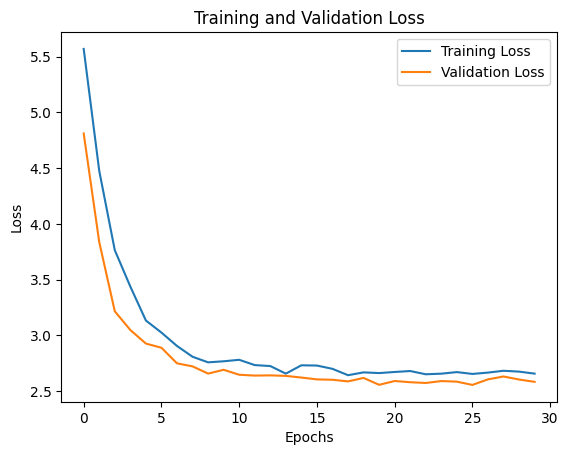

In [62]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(loc='best')
plt.show()

# Testing and Inference

In [ ]:
# todo ...